In [1]:
import sys
import os

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


In [2]:
X1 = pd.read_csv("mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("mod_data/y3.1", index_col="QSPRID")


In [3]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [4]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=1, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)

In [5]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit_transform(X1)
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

In [6]:
n_components

1821

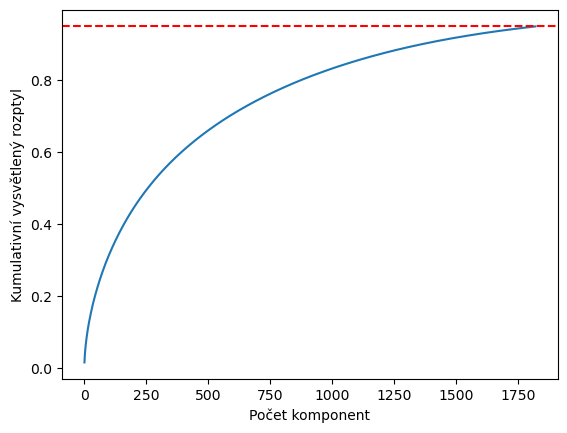

In [7]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [8]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


KeyboardInterrupt: 

In [9]:
pred = svc.predict(X2)

In [10]:
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score

print("Acc:", accuracy_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.7306096393233322
Mcc: 0.4390531916893105


In [21]:
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score
from tqdm import tqdm
import pandas as pd
param_grid = ParameterGrid({
    'C': np.logspace(-3, 2, num=6).tolist(), # Např. [0.01, 0.1, 1.0, 10.0, 100.0]
    'kernel': ['linear', 'rbf', 'poly'], # Omezeno na nejčastější kernely
    'gamma': np.logspace(-2, 1, num=4).tolist(), # Např. [0.01, 0.1, 1.0, 10.0] - relevantní pro 'rbf'
})

val_mcc = []
val_f1 = []
val_acc = []
comb_tried = []
for param in tqdm(param_grid, total=len(param_grid)):
    if param['kernel'] == 'linear' and param['C'] in comb_tried:
        val_mcc.append(-2)
        val_f1.append(-1)
        val_acc.append(-1)
        print("Params skipped:", param,)
        pass
    else:
        if param['kernel'] == 'linear':
            comb_tried.append(param['C'])
        svc = SVC(random_state=69, **param)
        svc.fit(X1, y1["Y"])
        pred_svc = svc.predict(X2)
        val_mcc.append(matthews_corrcoef(pred_svc, y2["Y"]))
        val_f1.append(f1_score(pred_svc, y2["Y"]))
        val_acc.append(accuracy_score(pred_svc, y2["Y"]))
        print("Params:", param, "\nMCC:", matthews_corrcoef(pred_svc, y2["Y"]))



  1%|▋                                               | 1/72 [00:46<54:29, 46.04s/it]

Params: {'C': 0.001, 'gamma': 0.01, 'kernel': 'linear'} 
MCC: 0.3819486173589358


  3%|█▎                                            | 2/72 [02:40<1:40:36, 86.24s/it]

Params: {'C': 0.001, 'gamma': 0.01, 'kernel': 'rbf'} 
MCC: 0.0


  4%|█▉                                            | 3/72 [04:33<1:53:24, 98.62s/it]

...

Params: {'C': 100.0, 'gamma': 1.0, 'kernel': 'poly'} 
MCC: 0.3245375222404811
Params skipped: {'C': 100.0, 'gamma': 10.0, 'kernel': 'linear'}


 99%|███████████████████████████████████████████▍| 71/72 [4:43:49<04:07, 247.98s/it]

Params: {'C': 100.0, 'gamma': 10.0, 'kernel': 'rbf'} 
MCC: 0.0


100%|████████████████████████████████████████████| 72/72 [8:08:58<00:00, 407.49s/it]

Params: {'C': 100.0, 'gamma': 10.0, 'kernel': 'poly'} 
MCC: 0.32404578136375145


In [22]:
import pandas as pd
svc_res = pd.DataFrame(param_grid)

In [23]:
svc_res["mcc"] = val_mcc
svc_res["f1"] = val_f1
svc_res["acc"] = val_acc

In [24]:
svc_res.sort_values(by=["mcc", "f1", "acc"], ascending=False, inplace=True)

In [25]:
svc_res.to_csv("res/svc_res_val_1.1.csv")


In [26]:
svc_res

,C,gamma,kernel,mcc,f1,acc
0,0.001,0.01,linear,0.381949,0.753577,0.703160
2,0.001,0.01,poly,0.366902,0.678061,0.669327
12,0.010,0.01,linear,0.348130,0.740878,0.687201
14,0.010,0.01,poly,0.336925,0.654878,0.651133
26,0.100,0.01,poly,0.327989,0.660043,0.650495
...,...,...,...,...,...,...
54,10.000,1.00,linear,-2.000000,-1.000000,-1.000000
57,10.000,10.00,linear,-2.000000,-1.000000,-1.000000
63,100.000,0.10,linear,-2.000000,-1.000000,-1.000000
66,100.000,1.00,linear,-2.000000,-1.000000,-1.000000


In [16]:
import numpy as np
best_params = param_grid[np.argmax(val_mcc)]

In [17]:
best_params

{'shrinking': True,
 'kernel': 'rbf',
 'gamma': 'scale',
 'degree': 2,
 'coef0': 0.0,
 'C': 1}

In [18]:
svc = SVC(**best_params)
svc.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/utils/validation.py:1229: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=1, degree=2)

In [21]:
pred = svc.predict(X2)

print("Acc:", accuracy_score(pred, y2))
print("F1:", f1_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.8709677419354839
F1: 0.5652173913043478
Mcc: 0.5315270296169605


In [20]:
pred_test = svc.predict(X3)

print("Acc:", accuracy_score(pred_test, y3))
print("F1:", f1_score(pred_test, y3))
print("Mcc:", matthews_corrcoef(pred_test, y3))

Acc: 0.7926829268292683
F1: 0.2608695652173913
Mcc: 0.1905198432638073
